In [3]:
from typing import Annotated, TypedDict
from langgraph.graph.message import AnyMessage, add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [4]:
from langchain_ollama.llms import OllamaLLM

llm = OllamaLLM(model='mistral')

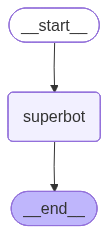

In [6]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

# Node definition
def superbot(state: State):
    return {'messages': [llm.invoke(state['messages'])]}

# Build Graph
builder = StateGraph(State)

# Node
builder.add_node('superbot', superbot)

# Edge
builder.add_edge(START, 'superbot')
builder.add_edge('superbot', END)

# Compile
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
from langchain_core.messages import HumanMessage, AIMessage

# Specify the thread
config = {'configurable': {'thread_id': '1'}}
messages = HumanMessage(content='Hey, my name is Aaron and i like cricket very much😀')
graph.invoke({'messages': messages}, config=config)

{'messages': [HumanMessage(content='Hey, my name is Aaron and i like cricket very much😀', additional_kwargs={}, response_metadata={}, id='79d5abb6-f75b-4927-b750-e988a69876de'),
  HumanMessage(content=" Hello Aaron! It's great to meet you. I'm here to chat. Cricket is a fascinating sport indeed. If you have any questions about cricket or would like to discuss some interesting topics related to it, feel free to ask! 😊", additional_kwargs={}, response_metadata={}, id='22ba37ff-079e-4252-95b1-61dee2299013')]}

### Streaming

Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- `values`: This streams the full state of the graph after each node is called.
- `updates`: This streams updates to the state of the graph after each node is called.

In [ ]:
# Create a thread
config = {'configurable': {'thread_id': '2'}}
messages = HumanMessage(content='Hey, my name is Aaron and i like cricket very much😀')

for chunk in graph.stream({'messages': messages}, config=config, stream_mode='updates'):
    print(chunk['superbot'])

{'messages': [" Hello Aaron! It sounds like we have a great time ahead discussing cricket. I'm excited to learn about your favorite team or player in the sport. Feel free to share who you are supporting currently, whether it's a local team or an international player. Let's delve deeper into the world of cricket together and exchange thoughts on this exciting game! 😊"]}


In [15]:
# Create a thread
messages = HumanMessage(content='I also like footbll ⚽')

for chunk in graph.stream({'messages': messages}, config=config, stream_mode='values'):
    print(chunk)

{'messages': [HumanMessage(content='Hey, my name is Aaron and i like cricket very much😀', additional_kwargs={}, response_metadata={}, id='740e9648-53ed-45e9-a489-62bcffec301c'), HumanMessage(content=" Hello Aaron! It's great to meet you. Cricket is a fascinating sport, isn't it? Do you have a favorite team or player? Let's discuss cricket together. 😊", additional_kwargs={}, response_metadata={}, id='776dcf7d-20ca-4713-a8b3-01aa301c55d7'), HumanMessage(content='Hey, my name is Aaron and i like cricket very much😀', additional_kwargs={}, response_metadata={}, id='6ab782e2-cd89-45b6-ab09-f010ba81ddbb'), HumanMessage(content=" Hello Aaron! It's a pleasure to chat with someone who shares the same passion for cricket as I do. Cricket is indeed an exciting sport, full of thrilling moments and strategic gameplay.\n\nAs for favorite teams or players, it can vary greatly depending on personal preferences and geographical location. However, if you don't mind me asking, which team or player are you

In [16]:
# Create a thread
messages = HumanMessage(content='I too love briyani ♨️ food')

for chunk in graph.stream({'messages': messages}, config=config, stream_mode='values'):
    print(chunk)

{'messages': [HumanMessage(content='Hey, my name is Aaron and i like cricket very much😀', additional_kwargs={}, response_metadata={}, id='740e9648-53ed-45e9-a489-62bcffec301c'), HumanMessage(content=" Hello Aaron! It's great to meet you. Cricket is a fascinating sport, isn't it? Do you have a favorite team or player? Let's discuss cricket together. 😊", additional_kwargs={}, response_metadata={}, id='776dcf7d-20ca-4713-a8b3-01aa301c55d7'), HumanMessage(content='Hey, my name is Aaron and i like cricket very much😀', additional_kwargs={}, response_metadata={}, id='6ab782e2-cd89-45b6-ab09-f010ba81ddbb'), HumanMessage(content=" Hello Aaron! It's a pleasure to chat with someone who shares the same passion for cricket as I do. Cricket is indeed an exciting sport, full of thrilling moments and strategic gameplay.\n\nAs for favorite teams or players, it can vary greatly depending on personal preferences and geographical location. However, if you don't mind me asking, which team or player are you

In [17]:
# Create a thread
messages = HumanMessage(content='I too love briyani ♨️ food')

for chunk in graph.stream({'messages': messages}, config=config, stream_mode='updates'):
    print(chunk)

{'superbot': {'messages': [" Hello Aaron! It's great to meet someone who enjoys both cricket and biryani! While our conversation is primarily focused on cricket today, let me assure you that we can certainly chat about biryani as well at another time.\n\nNow, coming back to cricket, it would be wonderful to learn more about your favorite team or player in this sport. Whether it's a local team like Yorkshire County Cricket Club in England, or international stars such as Virat Kohli, Sachin Tendulkar, or Steve Smith, I'd love to hear your thoughts and share mine with you.\n\nOn the other hand, if you have any specific questions about cricket rules, player statistics, or interesting matches, feel free to ask! Let's delve deeper into the world of cricket together, and maybe even learn a thing or two from each other. Enjoy our shared passion for this fantastic game! 😊"]}}
